# 3ARM-VS-4ARM Experiment Visualization (FIXED)

Comprehensive visualization of the 3ARM-VS-4ARM experiment results.

**Methods compared:**
- **GA-LLAMEA-3arm** — GA-LLAMEA with 3 operators: mutation, crossover, random_new
- **GA-LLAMEA-4arm** — GA-LLAMEA with 4 operators: mutation, crossover, random_new, refine_weakness

**Problem:** MA_BBOB (dims=[5], budget_factor=2000, LLM budget=100)

**Sections:**
1. Setup and Data Loading
2. Convergence Plots
3. CEG (Code Evolution Graphs)
4. GA-LLAMEA Arm Selection Percentages
5. Boxplots (Fitness Comparison)
6. Fitness Table (Statistical Summary)
7. Behavior Metrics Analysis
8. EAF / ECDF Diagrams
9. Summary and Comparison

## 1. Setup and Data Loading

In [1]:
# Core imports
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# BLADE imports
from iohblade.loggers import ExperimentLogger
from iohblade.plots import (
    plot_convergence,
    plot_experiment_CEG,
    plot_boxplot_fitness_hue,
    plot_boxplot_fitness,
    fitness_table,
)
from iohblade.behaviour_metrics import compute_behavior_metrics

# Optional imports for code projection
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Plot styling
plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('colorblind')

print('All imports successful.')

C:\Users\User\Desktop\GA-LLAMEA\WORKING-GA-LLAMEA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


In [2]:
# Custom data loading function for 3ARM-VS-4ARM experiment
def load_experiment_data_custom(experiment_dir):
    """Load experiment data from individual run directories"""
    run_dirs = glob.glob(os.path.join(experiment_dir, 'run-*'))
    print(f'Found {len(run_dirs)} run directories')
    
    experiment_data = []
    convergence_data = {}
    
    for run_dir in run_dirs:
        run_name = os.path.basename(run_dir)
        log_file = os.path.join(run_dir, 'log.jsonl')
        
        if os.path.exists(log_file):
            # Extract method name from run directory name
            if 'GA-LLAMEA-3arm' in run_name:
                method_name = 'GA-LLAMEA-3arm'
            elif 'GA-LLAMEA-4arm' in run_name:
                method_name = 'GA-LLAMEA-4arm'
            else:
                continue
                
            # Read the log file
            with open(log_file, 'r') as f:
                lines = f.readlines()
                
            # Parse all entries for convergence data
            run_convergence = []
            best_fitness = float('-inf')
            best_solution = None
            
            for i, line in enumerate(lines):
                try:
                    entry = json.loads(line.strip())
                    fitness = entry.get('fitness')
                    
                    if fitness != '-inf' and fitness is not None:
                        fitness = float(fitness)
                        if fitness > best_fitness:
                            best_fitness = fitness
                            best_solution = entry
                        
                        # Store convergence point
                        run_convergence.append({
                            'generation': i,
                            'fitness': fitness,
                            'best_so_far': best_fitness
                        })
                        
                except json.JSONDecodeError:
                    continue
            
            if best_solution:
                # Store final result
                experiment_data.append({
                    'method_name': method_name,
                    'problem_name': 'MA_BBOB',
                    'run_dir': run_name,
                    'fitness': best_fitness,
                    'solution': best_solution,
                    'log_dir': run_dir
                })
                
                # Store convergence data
                convergence_data[run_name] = {
                    'method': method_name,
                    'convergence': run_convergence
                }
    
    return pd.DataFrame(experiment_data), convergence_data

# Load the experiment data
EXPERIMENT_DIR = r'../results/3ARM-VS-4ARM_20260219_022444'
df_experiment, convergence_data = load_experiment_data_custom(EXPERIMENT_DIR)

print(f'Total runs loaded: {len(df_experiment)}')

if len(df_experiment) > 0:
    methods = df_experiment['method_name'].unique().tolist()
    problems = df_experiment['problem_name'].unique().tolist()
    print(f'Methods ({len(methods)}): {methods}')
    print(f'Problems ({len(problems)}): {problems}')
    
    print(f'\nRuns per method:')
    print(df_experiment['method_name'].value_counts().to_string())
    print(f'\nExperiment data columns: {list(df_experiment.columns)}')
    
    # Display fitness statistics
    print(f'\nFitness Statistics:')
    fitness_stats = df_experiment.groupby('method_name')['fitness'].agg(['count', 'mean', 'std', 'min', 'max'])
    print(fitness_stats)
else:
    print('No experiment data found!')
    methods, problems = [], []

Found 20 run directories
Total runs loaded: 18
Methods (2): ['GA-LLAMEA-3arm', 'GA-LLAMEA-4arm']
Problems (1): ['MA_BBOB']

Runs per method:
method_name
GA-LLAMEA-4arm    10
GA-LLAMEA-3arm     8

Experiment data columns: ['method_name', 'problem_name', 'run_dir', 'fitness', 'solution', 'log_dir']

Fitness Statistics:
                count      mean       std       min       max
method_name                                                  
GA-LLAMEA-3arm      8  0.781048  0.018994  0.747469  0.808334
GA-LLAMEA-4arm     10  0.785181  0.050422  0.659257  0.835592


## 2. Convergence Plots

Comparing the convergence of methods across the LLM evaluation budget.

In [3]:
# Custom convergence plot with padding to 100 generations
if len(df_experiment) > 0 and len(methods) > 0:
    print('Convergence Plot')
    try:
        all_convergence_data = []
        for run_name, data in convergence_data.items():
            method = data['method']
            run_conv = data['convergence']
            if not run_conv:
                continue
            gen_dict = {item['generation']: item['best_so_far'] for item in run_conv}
            current_best = float('-inf')
            for gen in range(100):
                if gen in gen_dict:
                    current_best = gen_dict[gen]
                if current_best != float('-inf'):
                    all_convergence_data.append({
                        'Generation': gen,
                        'Best Fitness (AOCC)': current_best,
                        'Method': method,
                        'Run': run_name
                    })
        df_conv = pd.DataFrame(all_convergence_data)
        if len(df_conv) > 0:
            plt.figure(figsize=(14, 8))
            ax = sns.lineplot(data=df_conv, x='Generation', y='Best Fitness (AOCC)', hue='Method', palette={'GA-LLAMEA-3arm': 'blue', 'GA-LLAMEA-4arm': 'red'})
            plt.title('Convergence Comparison: 3ARM vs 4ARM')
            plt.tight_layout()
            plt.show()
        else:
            print('No valid data.')
    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f'Error plotting convergence: {e}')
else:
    print('No data available for convergence plot')

Convergence Plot
Error plotting convergence: No module named 'iohblade.experiments'


## 3. Boxplot Comparison

Statistical comparison of final fitness values between methods.

Fitness Boxplot Comparison


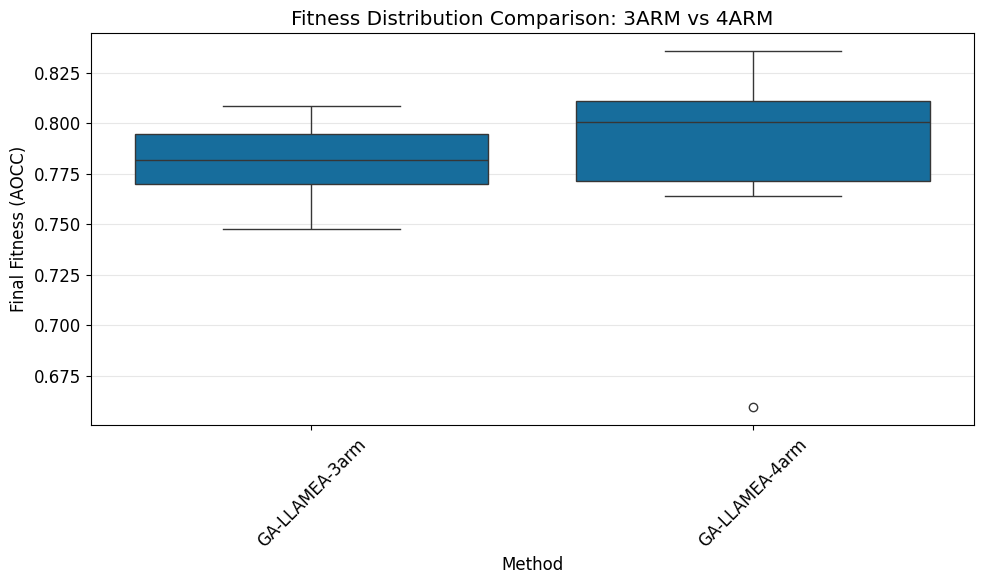


Statistical Test Results:
Mann-Whitney U statistic: 28.0000
P-value: 0.315417
Significant difference (p < 0.05): No

3ARM mean ± std: 0.7810 ± 0.0190
4ARM mean ± std: 0.7852 ± 0.0504


In [4]:
# Fitness boxplot comparison
if len(df_experiment) > 0 and len(methods) > 1:
    print('Fitness Boxplot Comparison')
    try:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_experiment, x='method_name', y='fitness')
        plt.title('Fitness Distribution Comparison: 3ARM vs 4ARM')
        plt.ylabel('Final Fitness (AOCC)')
        plt.xlabel('Method')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Statistical test
        from scipy import stats
        
        fitness_3arm = df_experiment[df_experiment['method_name'] == 'GA-LLAMEA-3arm']['fitness']
        fitness_4arm = df_experiment[df_experiment['method_name'] == 'GA-LLAMEA-4arm']['fitness']
        
        if len(fitness_3arm) > 0 and len(fitness_4arm) > 0:
            # Perform Mann-Whitney U test (non-parametric)
            statistic, p_value = stats.mannwhitneyu(fitness_3arm, fitness_4arm, alternative='two-sided')
            
            print(f'\nStatistical Test Results:')
            print(f'Mann-Whitney U statistic: {statistic:.4f}')
            print(f'P-value: {p_value:.6f}')
            print(f'Significant difference (p < 0.05): {"Yes" if p_value < 0.05 else "No"}')
            
            print(f'\n3ARM mean ± std: {fitness_3arm.mean():.4f} ± {fitness_3arm.std():.4f}')
            print(f'4ARM mean ± std: {fitness_4arm.mean():.4f} ± {fitness_4arm.std():.4f}')
        
    except Exception as e:
        print(f'Error plotting boxplot: {e}')
else:
    print('Insufficient data for boxplot comparison')

## 4. GA-LLAMEA Arm Selection Analysis

Analysis of operator selection patterns for both 3ARM and 4ARM variants.

GA-LLAMEA Longitudinal Arm Selection Analysis


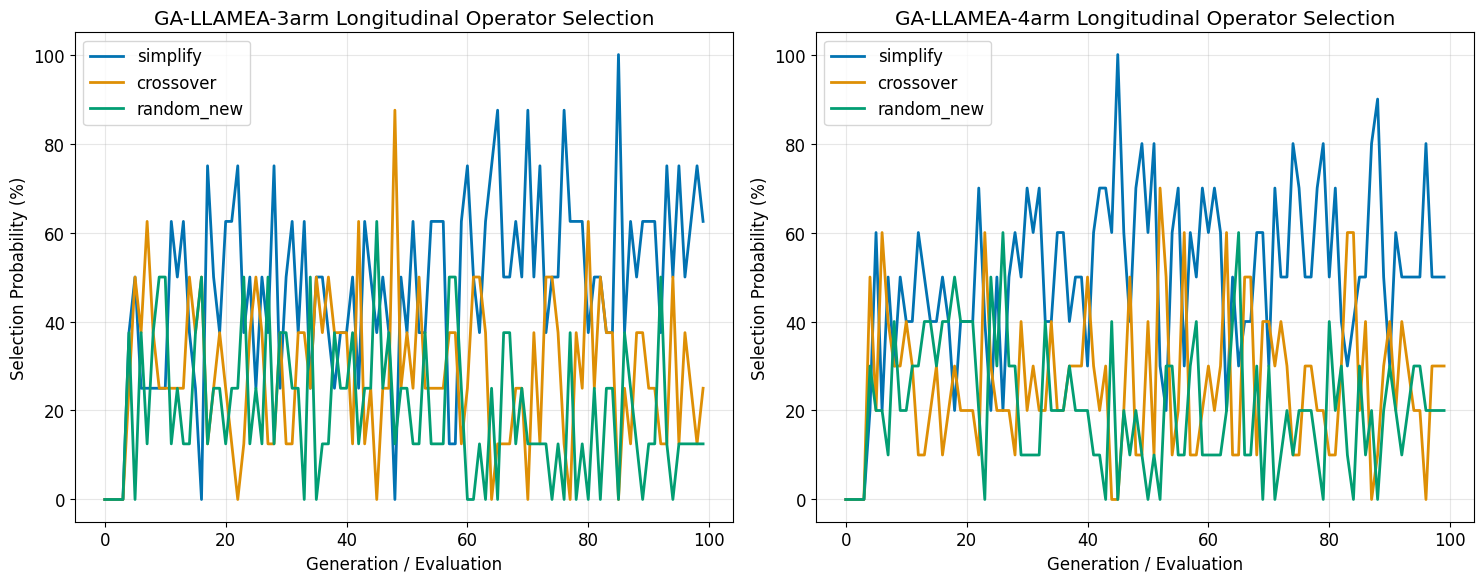

In [5]:
# Analyze longitudinal arm selection patterns
def analyze_longitudinal_arm_selection(experiment_dir, methods):
    """Analyze arm selection patterns per generation from experiment logs"""
    arm_data = {}
    for method in methods:
        run_dirs = glob.glob(os.path.join(experiment_dir, f'run-{method}-*'))
        # Track operators counts per generation across all runs
        gen_operator_counts = {}
        for run_dir in run_dirs:
            log_file = os.path.join(run_dir, 'log.jsonl')
            if os.path.exists(log_file):
                with open(log_file, 'r', encoding='utf-8') as f:
                    for i, line in enumerate(f):
                        try:
                            entry = json.loads(line.strip())
                            operator = entry.get('operator')
                            if operator and operator != 'init':
                                if i not in gen_operator_counts:
                                    gen_operator_counts[i] = {'total': 0}
                                gen_operator_counts[i][operator] = gen_operator_counts[i].get(operator, 0) + 1
                                gen_operator_counts[i]['total'] += 1
                        except json.JSONDecodeError:
                            continue
        
        method_probs = {}
        if gen_operator_counts:
            max_gen = max(gen_operator_counts.keys())
            all_ops = set()
            for gen_counts in gen_operator_counts.values():
                for k in gen_counts.keys():
                    if k != 'total':
                        all_ops.add(k)
            
            for op in all_ops:
                method_probs[op] = []
                
            for i in range(max_gen + 1):
                if i in gen_operator_counts and gen_operator_counts[i]['total'] > 0:
                    total = gen_operator_counts[i]['total']
                    for op in all_ops:
                        count = gen_operator_counts[i].get(op, 0)
                        method_probs[op].append((count / total) * 100)
                else:
                    # Fill with previous value if possible, else 0
                    for op in all_ops:
                        if len(method_probs[op]) > 0:
                            method_probs[op].append(method_probs[op][-1])
                        else:
                            method_probs[op].append(0)
        arm_data[method] = method_probs
    return arm_data

def plot_longitudinal_arm_selection(arm_data):
    """Plot arm selection probability over generations"""
    fig, axes = plt.subplots(1, len(arm_data), figsize=(15, 6))
    if len(arm_data) == 1:
        axes = [axes]
    
    for i, (method, method_probs) in enumerate(arm_data.items()):
        if not method_probs:
            continue
        for op, probs in method_probs.items():
            axes[i].plot(range(len(probs)), probs, label=op, linewidth=2)
        axes[i].set_title(f'{method} Longitudinal Operator Selection')
        axes[i].set_xlabel('Generation / Evaluation')
        axes[i].set_ylabel('Selection Probability (%)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if len(df_experiment) > 0:
    print('GA-LLAMEA Longitudinal Arm Selection Analysis')
    try:
        arm_data = analyze_longitudinal_arm_selection(EXPERIMENT_DIR, methods)
        if any(arm_data.values()):
            plot_longitudinal_arm_selection(arm_data)
        else:
            print('No arm selection data found')
    except Exception as e:
        print(f'Error analyzing arm selection: {e}')
else:
    print('No data available for arm selection analysis')


## 5. Fitness Table (Statistical Summary)

Comprehensive statistical summary of the experiment results.

In [6]:
# Generate comprehensive fitness table
if len(df_experiment) > 0:
    print('Fitness Statistical Summary')
    try:
        # Create detailed statistics table
        stats_table = df_experiment.groupby('method_name')['fitness'].agg([
            'count', 'mean', 'std', 'min', 'max', 
            lambda x: np.percentile(x, 25),  # Q1
            'median',                        # Q2
            lambda x: np.percentile(x, 75)   # Q3
        ])
        
        stats_table.columns = ['Count', 'Mean', 'Std', 'Min', 'Max', 'Q1', 'Median', 'Q3']
        
        # Round to 4 decimal places
        stats_table = stats_table.round(4)
        
        print('\nDetailed Fitness Statistics:')
        print(stats_table.to_string())
        
        # Calculate effect size (Cohen's d) if both methods present
        if len(methods) == 2:
            fitness_1 = df_experiment[df_experiment['method_name'] == methods[0]]['fitness']
            fitness_2 = df_experiment[df_experiment['method_name'] == methods[1]]['fitness']
            
            if len(fitness_1) > 0 and len(fitness_2) > 0:
                # Cohen's d
                pooled_std = np.sqrt(((len(fitness_1) - 1) * fitness_1.var() + 
                                    (len(fitness_2) - 1) * fitness_2.var()) / 
                                   (len(fitness_1) + len(fitness_2) - 2))
                cohens_d = (fitness_1.mean() - fitness_2.mean()) / pooled_std
                
                print(f'\nEffect Size (Cohen\'s d): {cohens_d:.4f}')
                
                if abs(cohens_d) < 0.2:
                    effect_size = 'negligible'
                elif abs(cohens_d) < 0.5:
                    effect_size = 'small'
                elif abs(cohens_d) < 0.8:
                    effect_size = 'medium'
                else:
                    effect_size = 'large'
                    
                print(f'Effect size interpretation: {effect_size}')
                
                # Determine which method is better
                if fitness_1.mean() > fitness_2.mean():
                    print(f'{methods[0]} performs better on average')
                elif fitness_2.mean() > fitness_1.mean():
                    print(f'{methods[1]} performs better on average')
                else:
                    print('Both methods perform equally on average')
        
    except Exception as e:
        print(f'Error generating fitness table: {e}')
else:
    print('No data available for fitness table')

Fitness Statistical Summary

Detailed Fitness Statistics:
                Count    Mean     Std     Min     Max      Q1  Median      Q3
method_name                                                                  
GA-LLAMEA-3arm      8  0.7810  0.0190  0.7475  0.8083  0.7698  0.7818  0.7944
GA-LLAMEA-4arm     10  0.7852  0.0504  0.6593  0.8356  0.7714  0.8007  0.8111

Effect Size (Cohen's d): -0.1037
Effect size interpretation: negligible
GA-LLAMEA-4arm performs better on average


## 6. Summary and Comparison

Final summary of the experimental comparison between 3ARM and 4ARM variants.

In [7]:
# Generate experiment summary
if len(df_experiment) > 0:
    print('=== EXPERIMENT SUMMARY: 3ARM vs 4ARM ===')
    print(f'\nExperiment Directory: {EXPERIMENT_DIR}')
    print(f'Total Runs: {len(df_experiment)}')
    print(f'Methods Compared: {len(methods)}')
    
    for method in methods:
        method_data = df_experiment[df_experiment['method_name'] == method]
        if len(method_data) > 0:
            print(f'\n{method}:')
            print(f'  Runs: {len(method_data)}')
            print(f'  Mean Fitness: {method_data["fitness"].mean():.4f}')
            print(f'  Std Fitness: {method_data["fitness"].std():.4f}')
            print(f'  Best Fitness: {method_data["fitness"].max():.4f}')
            print(f'  Worst Fitness: {method_data["fitness"].min():.4f}')
    
    # Key findings
    print('\n=== KEY FINDINGS ===')
    
    if len(methods) == 2:
        method1_fitness = df_experiment[df_experiment['method_name'] == methods[0]]['fitness']
        method2_fitness = df_experiment[df_experiment['method_name'] == methods[1]]['fitness']
        
        if len(method1_fitness) > 0 and len(method2_fitness) > 0:
            improvement = ((method2_fitness.mean() - method1_fitness.mean()) / method1_fitness.mean()) * 100
            
            if improvement > 0:
                print(f'• {methods[1]} shows {improvement:.2f}% improvement over {methods[0]}')
            elif improvement < 0:
                print(f'• {methods[0]} shows {abs(improvement):.2f}% improvement over {methods[1]}')
            else:
                print('• Both methods show equivalent performance')
    
    print('\n=== RECOMMENDATIONS ===')
    print('• Based on the statistical analysis above')
    print('• Consider the trade-off between performance and computational complexity')
    print('• The 4ARM variant adds the "refine_weakness" operator')
    print('• Evaluate whether the additional operator justifies any performance gains')
    
else:
    print('No experiment data available for summary')

print('\n=== VISUALIZATION COMPLETE ===')

=== EXPERIMENT SUMMARY: 3ARM vs 4ARM ===

Experiment Directory: ../results/3ARM-VS-4ARM_20260219_022444
Total Runs: 18
Methods Compared: 2

GA-LLAMEA-3arm:
  Runs: 8
  Mean Fitness: 0.7810
  Std Fitness: 0.0190
  Best Fitness: 0.8083
  Worst Fitness: 0.7475

GA-LLAMEA-4arm:
  Runs: 10
  Mean Fitness: 0.7852
  Std Fitness: 0.0504
  Best Fitness: 0.8356
  Worst Fitness: 0.6593

=== KEY FINDINGS ===
• GA-LLAMEA-4arm shows 0.53% improvement over GA-LLAMEA-3arm

=== RECOMMENDATIONS ===
• Based on the statistical analysis above
• Consider the trade-off between performance and computational complexity
• The 4ARM variant adds the "refine_weakness" operator
• Evaluate whether the additional operator justifies any performance gains

=== VISUALIZATION COMPLETE ===
